In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    path = fetch("data/retail_demand.csv")
except NameError:
    path = "data/retail_demand.csv"

SEED = 42
np.random.seed(SEED)


## 1. Time Series Structure & Diagnostics

Rows after filtering: 1096
Duplicate dates: 0
2023-01-01 00:00:00 to 2025-12-31 00:00:00
Missing: 0
Remaining NaN: 0


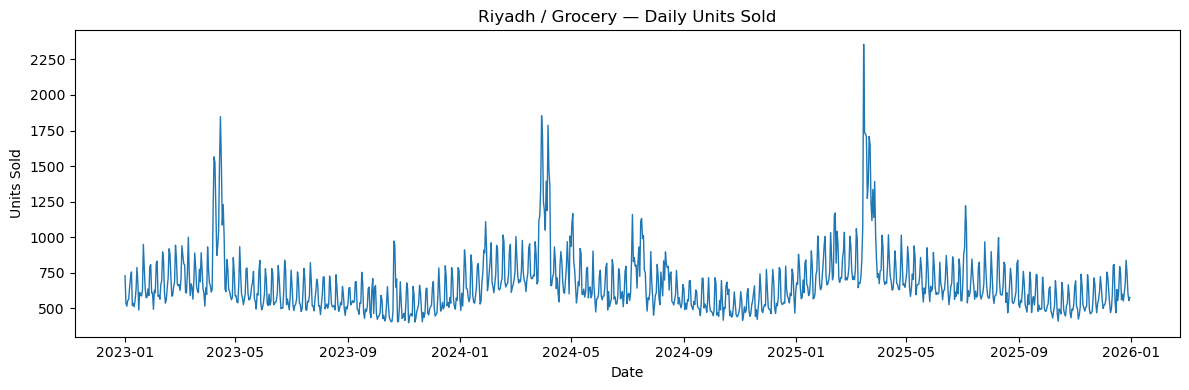

In [2]:
df = pd.read_csv("retail_demand.csv")

# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Filter
riyadh_grocery = df[
    (df["region"] == "Riyadh") &
    (df["category"] == "Grocery")
].copy()

print("Rows after filtering:", len(riyadh_grocery))

# Sort
riyadh_grocery = riyadh_grocery.sort_values("date")

# Check duplicates
print("Duplicate dates:",
      riyadh_grocery["date"].duplicated().sum())

# Aggregate if multiple records exist for same day
riyadh_grocery = (
    riyadh_grocery
    .groupby("date")["units_sold"]
    .sum()
    .sort_index()
)

# Convert to daily frequency
y = riyadh_grocery.asfreq("D")

print(y.index.min(), "to", y.index.max())
print("Missing:", y.isna().sum())

# Interpolate missing values
y = y.interpolate(method="time")

print("Remaining NaN:", y.isna().sum())

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(y.index, y.values, linewidth=1)

ax.set_title("Riyadh / Grocery — Daily Units Sold")
ax.set_xlabel("Date")
ax.set_ylabel("Units Sold")

plt.tight_layout()
plt.show()

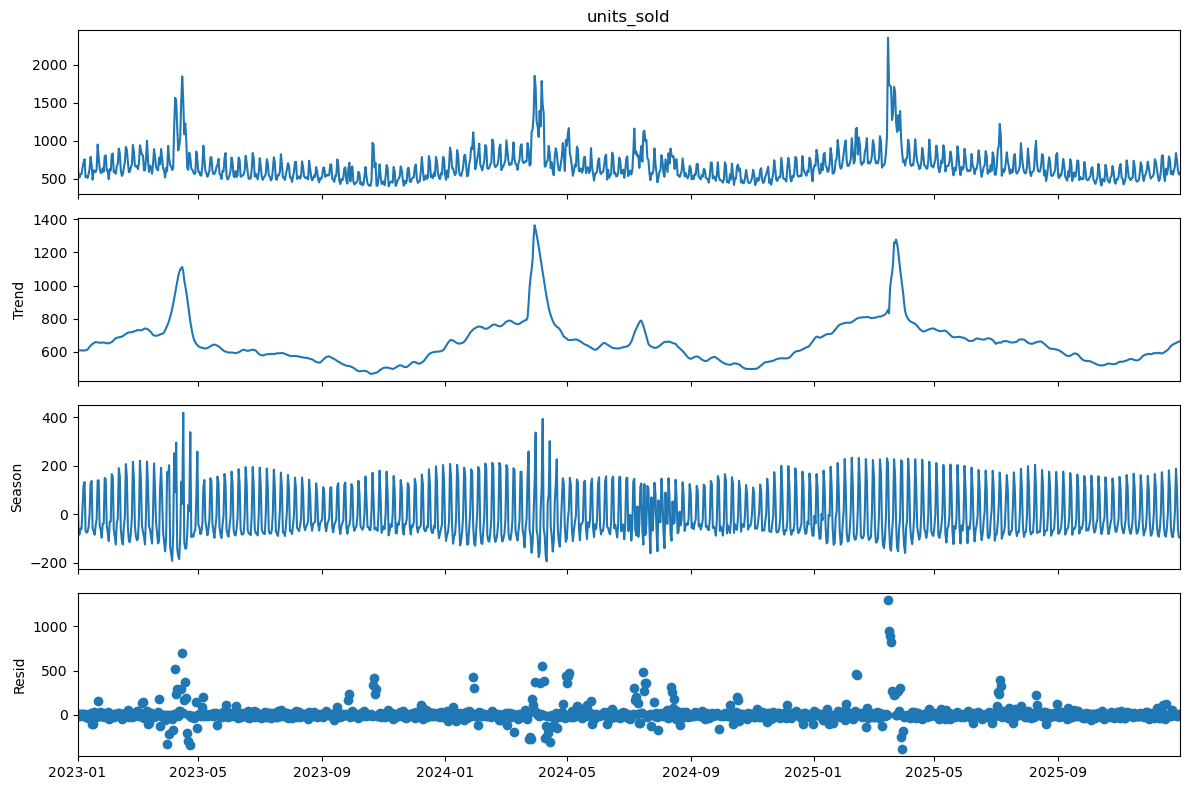

In [3]:
# STL decomposition with weekly seasonality.
stl = STL(y, period=7, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


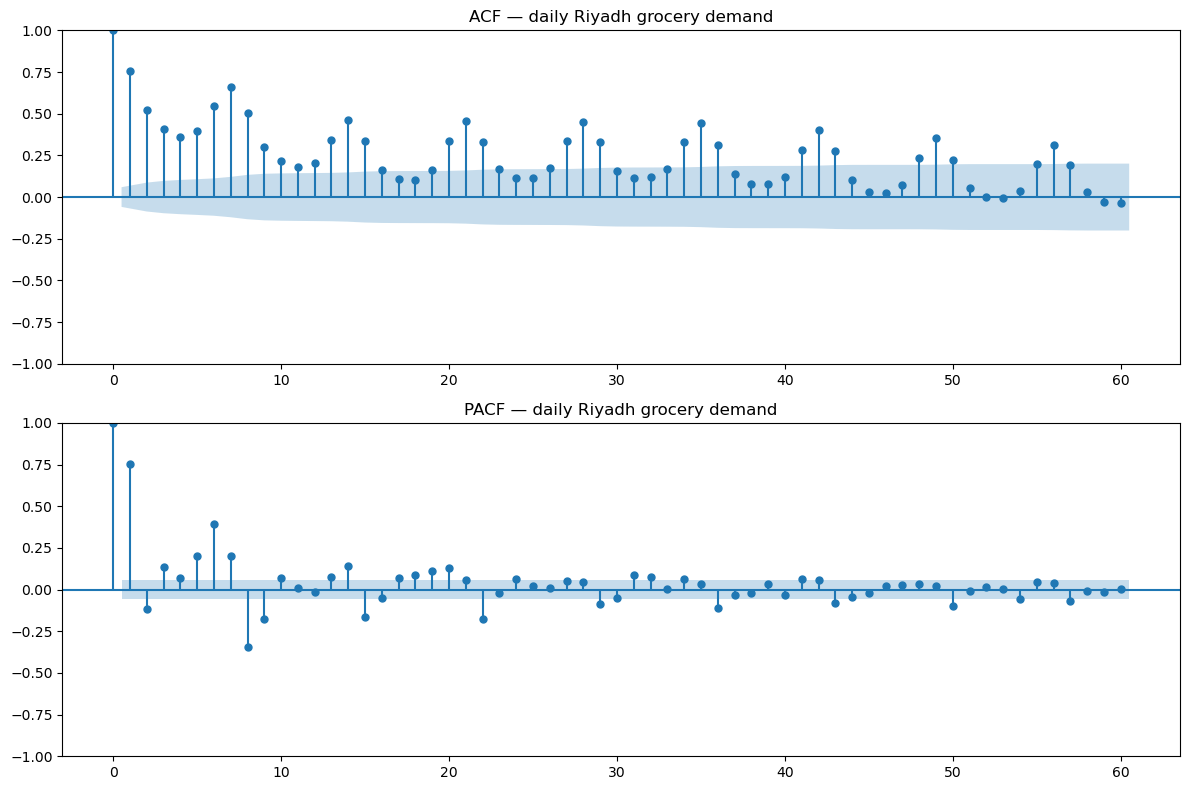

ADF statistic (level): -3.8721
ADF p-value (level): 0.002250
Interpretation: reject the unit-root null at the 5% level; the level series is consistent with stationarity.


In [4]:
# ACF/PACF: inspect short and weekly lags.
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plot_acf(y.dropna(), lags=min(60, len(y)//3), ax=axes[0], alpha=0.05)
axes[0].set_title("ACF — daily Riyadh grocery demand")
plot_pacf(y.dropna(), lags=min(60, len(y)//3), ax=axes[1], alpha=0.05, method="ywm")
axes[1].set_title("PACF — daily Riyadh grocery demand")
plt.tight_layout()
plt.show()

adf_level = adfuller(y.dropna(), autolag="AIC")
print(f"ADF statistic (level): {adf_level[0]:.4f}")
print(f"ADF p-value (level): {adf_level[1]:.6f}")

if adf_level[1] < 0.05:
    print("Interpretation: reject the unit-root null at the 5% level; the level series is consistent with stationarity.")
    y_model = y.copy()
    d_order = 0
else:
    print("Interpretation: fail to reject the unit-root null at the 5% level; differencing is indicated before a non-seasonal ARIMA component.")
    y_model = y.diff().dropna()
    d_order = 1
    adf_diff = adfuller(y_model, autolag="AIC")
    print(f"ADF p-value after first difference: {adf_diff[1]:.6f}")


### Diagnostic interpretation

The ADF p-value is used as a stationarity decision point rather than being reported without interpretation. The weekly STL component and ACF spikes around lag 7 are evidence to inspect weekly seasonality explicitly. Any differencing decision is carried into the classical-model specification instead of being chosen arbitrarily.

## 2. Classical Forecasting Model — SARIMA

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from common.metrics import mae, rmse

HOLDOUT = min(28, max(14, len(y) // 10))

train_classical = y.iloc[:-HOLDOUT]
test_classical = y.iloc[-HOLDOUT:]



candidate_orders = [
    (0, d_order, 1),
    (1, d_order, 0),
    (1, d_order, 1),
    (2, d_order, 1),
]

candidate_seasonal_orders = [
    (0, 0, 0, 7),
    (1, 0, 0, 7),
    (0, 0, 1, 7),
    (1, 0, 1, 7),
]

sarima_results = []

for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:

        try:
            model = SARIMAX(
                train_classical,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted = model.fit(disp=False)

            sarima_results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted.aic,
                "BIC": fitted.bic
            })

        except Exception as e:
            print(
                f"Failed: order={order}, "
                f"seasonal_order={seasonal_order}: {e}"
            )


sarima_comparison = pd.DataFrame(sarima_results)

print("SARIMA candidate comparison:")
display(
    sarima_comparison
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)


best_row = (
    sarima_comparison
    .sort_values(["AIC", "BIC"])
    .iloc[0]
)

BEST_ORDER = best_row["order"]
BEST_SEASONAL_ORDER = best_row["seasonal_order"]

print("\nSelected SARIMA configuration:")
print("Order:", BEST_ORDER)
print("Seasonal order:", BEST_SEASONAL_ORDER)
print("AIC:", best_row["AIC"])
print("BIC:", best_row["BIC"])



sarima = SARIMAX(
    train_classical,
    order=BEST_ORDER,
    seasonal_order=BEST_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

classical_pred = sarima.forecast(HOLDOUT)

mae_classical = mae(
    test_classical,
    classical_pred
)

rmse_classical = rmse(
    test_classical,
    classical_pred
)

print(f"\nSARIMA holdout MAE: {mae_classical:.3f}")
print(f"SARIMA holdout RMSE: {rmse_classical:.3f}")



resid = sarima.resid.dropna()

lb = acorr_ljungbox(
    resid,
    lags=[7, 14],
    return_df=True
)

print("\nLjung-Box residual diagnostic:")
display(lb)



ets = ExponentialSmoothing(
    train_classical,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()

ets_pred = ets.forecast(HOLDOUT)

mae_ets = mae(
    test_classical,
    ets_pred
)

rmse_ets = rmse(
    test_classical,
    ets_pred
)

print("\nExponential Smoothing results:")
print(f"ETS holdout MAE: {mae_ets:.3f}")
print(f"ETS holdout RMSE: {rmse_ets:.3f}")

c:\Users\foooo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\foooo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\foooo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA candidate comparison:


c:\Users\foooo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,order,seasonal_order,AIC,BIC
0,"(1, 0, 1)","(1, 0, 1, 7)",12726.258683,12751.084085
1,"(1, 0, 0)","(1, 0, 1, 7)",12762.571436,12782.435533
2,"(2, 0, 1)","(1, 0, 1, 7)",12924.321532,12954.112014
3,"(2, 0, 1)","(1, 0, 0, 7)",13109.962147,13134.787548
4,"(1, 0, 1)","(1, 0, 0, 7)",13140.031081,13159.895177
5,"(1, 0, 0)","(1, 0, 0, 7)",13175.143008,13190.041080
6,"(1, 0, 1)","(0, 0, 1, 7)",13303.376445,13323.236767
7,"(1, 0, 0)","(0, 0, 1, 7)",13335.161317,13350.059389
8,"(0, 0, 1)","(1, 0, 0, 7)",13530.192981,13545.093883
9,"(0, 0, 1)","(1, 0, 1, 7)",13578.118338,13597.978659



Selected SARIMA configuration:
Order: (1, 0, 1)
Seasonal order: (1, 0, 1, 7)
AIC: 12726.258682832286
BIC: 12751.084084560292

SARIMA holdout MAE: 28.991
SARIMA holdout RMSE: 38.732

Ljung-Box residual diagnostic:


c:\Users\foooo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,lb_stat,lb_pvalue
7,15.799043,0.027017
14,31.592719,0.004575



Exponential Smoothing results:
ETS holdout MAE: 50.150
ETS holdout RMSE: 59.191


## 3. ML/GBM Forecasting & Temporal Feature Engineering

In [6]:
LAGS = [1, 2, 3, 7, 14, 21, 28]
ROLL_WINDOWS = [7, 14, 28]

def make_features(series):
    out = pd.DataFrame({"y": series})
    for lag in LAGS:
        out[f"lag_{lag}"] = series.shift(lag)
    for w in ROLL_WINDOWS:
        shifted = series.shift(1)
        out[f"rolling_mean_{w}"] = shifted.rolling(w).mean()
        out[f"rolling_std_{w}"] = shifted.rolling(w).std()
    out["day_of_week"] = series.index.dayofweek
    out["is_weekend"] = (series.index.dayofweek >= 5).astype(int)
    out["day_of_month"] = series.index.day
    out["month"] = series.index.month
    out["week_of_year"] = series.index.isocalendar().week.astype(int).values
    return out

features = make_features(y).dropna()
feature_cols = [c for c in features.columns if c != "y"]
print("Feature rows:", len(features))
print("Features:", feature_cols)


Feature rows: 1068
Features: ['lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_21', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_28', 'rolling_std_28', 'day_of_week', 'is_weekend', 'day_of_month', 'month', 'week_of_year']


In [7]:

from lightgbm import LGBMRegressor

gbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    max_depth=-1,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=-1
)

gbm.fit(
    features[feature_cols],
    features["y"]
)

last_row = features.iloc[[-1]]

print("LightGBM trained on", len(features), "leakage-safe feature rows.")

  File "c:\Users\foooo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\foooo\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\foooo\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\foooo\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LightGBM trained on 1068 leakage-safe feature rows.


## 4. Walk-Forward Backtesting — 4 Expanding Folds

In [8]:

def make_feature_row(history, date):
    s = history

    row = {}

    for lag in LAGS:
        row[f"lag_{lag}"] = s.iloc[-lag]

    for w in ROLL_WINDOWS:
        vals = s.iloc[-w:]
        row[f"rolling_mean_{w}"] = vals.mean()
        row[f"rolling_std_{w}"] = vals.std()


    row["day_of_week"] = date.dayofweek
    row["is_weekend"] = int(date.dayofweek >= 5)
    row["day_of_month"] = date.day
    row["month"] = date.month
    row["week_of_year"] = int(date.isocalendar().week)

    return pd.DataFrame(
        [row],
        index=[date]
    )[feature_cols]



from lightgbm import LGBMRegressor

def recursive_gbm_forecast(train_series, horizon):

    train_feat = make_features(train_series).dropna()


    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=15,
        reg_lambda=1.0,
        random_state=SEED,
        verbosity=-1
    )

    model.fit(
        train_feat[feature_cols],
        train_feat["y"]
    )

    history = train_series.copy()
    preds = []

    for _ in range(horizon):

        next_date = (
            history.index[-1]
            + pd.Timedelta(days=1)
        )

        x_next = make_feature_row(
            history,
            next_date
        )

        pred = float(
            model.predict(x_next)[0]
        )

        preds.append(pred)

        history.loc[next_date] = pred

    forecast_index = pd.date_range(
        start=train_series.index[-1]
        + pd.Timedelta(days=1),
        periods=horizon,
        freq="D"
    )

    return pd.Series(
        preds,
        index=forecast_index
    )



def seasonal_naive_forecast(
    train_series,
    horizon,
    seasonal_period=7
):

    last_season = train_series.iloc[-seasonal_period:].values

    preds = [
        last_season[i % seasonal_period]
        for i in range(horizon)
    ]

    forecast_index = pd.date_range(
        start=train_series.index[-1]
        + pd.Timedelta(days=1),
        periods=horizon,
        freq="D"
    )

    return pd.Series(
        preds,
        index=forecast_index
    )



from common.metrics import mae, rmse, mase, wape



H = 7
N_FOLDS = 4

min_train = max(
    60,
    len(y) - N_FOLDS * H - 1
)

expanding_rows = []

for fold in range(N_FOLDS):

    train_end = min_train + fold * H

    train = y.iloc[:train_end]

    test = y.iloc[
        train_end:train_end + H
    ]

    if len(test) < H:
        break

    pred = recursive_gbm_forecast(
        train,
        H
    )

    expanding_rows.append({
        "fold": fold + 1,
        "train_start": train.index[0],
        "train_end": train.index[-1],
        "test_start": test.index[0],
        "test_end": test.index[-1],
        "MAE": mae(test, pred),
        "RMSE": rmse(test, pred)
    })


expanding_results = pd.DataFrame(
    expanding_rows
)

print("EXPANDING WINDOW RESULTS")
display(expanding_results)

print(
    "Completed expanding folds:",
    len(expanding_results)
)



ROLLING_TRAIN_SIZE = min_train

rolling_rows = []

for fold in range(N_FOLDS):

    train_end = (
        ROLLING_TRAIN_SIZE
        + fold * H
    )

    train_start = (
        train_end
        - ROLLING_TRAIN_SIZE
    )

    train = y.iloc[
        train_start:train_end
    ]

    test = y.iloc[
        train_end:train_end + H
    ]

    if len(test) < H:
        break

    # Fresh LightGBM model inside each fold
    pred = recursive_gbm_forecast(
        train,
        H
    )

    rolling_rows.append({
        "fold": fold + 1,
        "train_start": train.index[0],
        "train_end": train.index[-1],
        "test_start": test.index[0],
        "test_end": test.index[-1],
        "MAE": mae(test, pred),
        "RMSE": rmse(test, pred)
    })


rolling_results = pd.DataFrame(
    rolling_rows
)

print("ROLLING WINDOW RESULTS")
display(rolling_results)

print(
    "Completed rolling folds:",
    len(rolling_results)
)


baseline_rows = []

for fold in range(N_FOLDS):

    train_end = min_train + fold * H

    train = y.iloc[:train_end]

    test = y.iloc[
        train_end:train_end + H
    ]

    if len(test) < H:
        break

    pred = seasonal_naive_forecast(
        train,
        H,
        seasonal_period=7
    )

    baseline_rows.append({
        "fold": fold + 1,
        "MAE": mae(test, pred),
        "RMSE": rmse(test, pred)
    })


seasonal_naive_results = pd.DataFrame(
    baseline_rows
)

print("SEASONAL-NAIVE BASELINE")
display(seasonal_naive_results)

print(
    "Seasonal-naive mean MAE:",
    seasonal_naive_results["MAE"].mean()
)

print(
    "Seasonal-naive mean RMSE:",
    seasonal_naive_results["RMSE"].mean()
)



comparison = pd.DataFrame({
    "Model": [
        "LightGBM - Expanding",
        "LightGBM - Rolling",
        "Seasonal Naive"
    ],
    "Mean MAE": [
        expanding_results["MAE"].mean(),
        rolling_results["MAE"].mean(),
        seasonal_naive_results["MAE"].mean()
    ],
    "Mean RMSE": [
        expanding_results["RMSE"].mean(),
        rolling_results["RMSE"].mean(),
        seasonal_naive_results["RMSE"].mean()
    ]
})

print("BACKTEST COMPARISON")
display(comparison)

EXPANDING WINDOW RESULTS


,fold,train_start,train_end,test_start,test_end,MAE,RMSE
0,1,2023-01-01,2025-12-02,2025-12-03,2025-12-09,34.944842,45.618702
1,2,2023-01-01,2025-12-09,2025-12-10,2025-12-16,48.565517,55.541011
2,3,2023-01-01,2025-12-16,2025-12-17,2025-12-23,41.654917,51.578779
3,4,2023-01-01,2025-12-23,2025-12-24,2025-12-30,31.543570,33.628582


Completed expanding folds: 4
ROLLING WINDOW RESULTS


,fold,train_start,train_end,test_start,test_end,MAE,RMSE
0,1,2023-01-01,2025-12-02,2025-12-03,2025-12-09,34.944842,45.618702
1,2,2023-01-08,2025-12-09,2025-12-10,2025-12-16,50.356401,56.795458
2,3,2023-01-15,2025-12-16,2025-12-17,2025-12-23,47.158872,55.634122
3,4,2023-01-22,2025-12-23,2025-12-24,2025-12-30,30.628451,33.302063


Completed rolling folds: 4
SEASONAL-NAIVE BASELINE


,fold,MAE,RMSE
0,1,45.142857,50.002857
1,2,57.142857,60.556939
2,3,65.714286,85.672132
3,4,44.428571,49.565253


Seasonal-naive mean MAE: 53.10714285714286
Seasonal-naive mean RMSE: 61.44929533170338
BACKTEST COMPARISON


,Model,Mean MAE,Mean RMSE
0,LightGBM - Expanding,39.177211,46.591768
1,LightGBM - Rolling,40.772142,47.837586
2,Seasonal Naive,53.107143,61.449295


## 5. Accuracy Metrics

In [9]:
from common.metrics import mae, rmse, mase, wape


# ============================================================
# Accuracy metrics for the expanding-window LightGBM backtest
# ============================================================

metric_rows = []

for fold in range(len(expanding_results)):

    train_end = min_train + fold * H

    train = y.iloc[:train_end]
    test = y.iloc[train_end:train_end + H]

    # Refit LightGBM using only data available before this fold
    pred = recursive_gbm_forecast(train, H)

    metric_rows.append({
        "fold": fold + 1,
        "MAE": mae(test, pred),
        "RMSE": rmse(test, pred),
        "MASE": mase(test, pred, train, 7),
        "WAPE": wape(test, pred),
    })


metrics_df = pd.DataFrame(metric_rows)

print("Fold-level accuracy metrics:")
display(metrics_df)


print("\nMean across folds:")

mean_metrics = (
    metrics_df
    .drop(columns="fold")
    .mean()
    .to_frame("mean")
)

display(mean_metrics)

Fold-level accuracy metrics:


,fold,MAE,RMSE,MASE,WAPE
0,1,34.944842,45.618702,0.392289,5.752914
1,2,48.565517,55.541011,0.546964,8.129092
2,3,41.654917,51.578779,0.470227,6.471026
3,4,31.543570,33.628582,0.356680,4.839031



Mean across folds:


,mean
MAE,39.177211
RMSE,46.591768
MASE,0.441540
WAPE,6.298016


## 6. Probabilistic Forecasting — Conformal Prediction Interval

Training observations: 1082
Calibration observations: 28
Future horizon: 14


12:05:59 - cmdstanpy - INFO - Chain [1] start processing
12:06:00 - cmdstanpy - INFO - Chain [1] done processing



PROPHET
Nominal coverage: 90%
Observed coverage: 100.00%
Mean interval width: 428.211


,actual,forecast,lower,upper
date,,,,
2025-12-18,553.0,557.409117,334.136541,773.792910
2025-12-19,625.0,603.989228,382.073645,826.593910
2025-12-20,793.0,795.783064,574.383066,1015.590762
2025-12-21,746.0,746.727890,542.604043,972.095825
2025-12-22,559.0,563.713621,351.406625,774.446729
2025-12-23,599.0,547.809152,338.997549,761.710351
2025-12-24,550.0,557.364644,336.691817,778.425128
2025-12-25,605.0,579.413161,372.104269,784.732060
2025-12-26,667.0,628.066910,399.738819,837.714409



SKTIME PREDICTION INTERVAL


...


Pinball Loss: 26.559790

CONFORMAL PREDICTION
Nominal coverage: 90%
Observed coverage: 100.00%
Mean interval width: 165.527 units


,actual,forecast,lower,upper
date,,,,
2025-12-18,553.0,577.071168,494.307730,659.834607
2025-12-19,625.0,583.599433,500.835995,666.362872
2025-12-20,793.0,744.862312,662.098873,827.625750
2025-12-21,746.0,728.009691,645.246252,810.773129
2025-12-22,559.0,553.088511,470.325072,635.851949
2025-12-23,599.0,528.600895,445.837456,611.364333
2025-12-24,550.0,558.889255,476.125817,641.652694
2025-12-25,605.0,571.233672,488.470234,653.997111
2025-12-26,667.0,595.322375,512.558937,678.085814



PROBABILISTIC FORECAST COMPARISON


,Method,Nominal Coverage,Observed Coverage,Mean Interval Width
0,Prophet,0.9,1.0,428.210726
1,sktime,0.9,1.0,681.782437
2,Conformal,0.9,1.0,165.526877



Sktime Pinball Loss: 26.559790


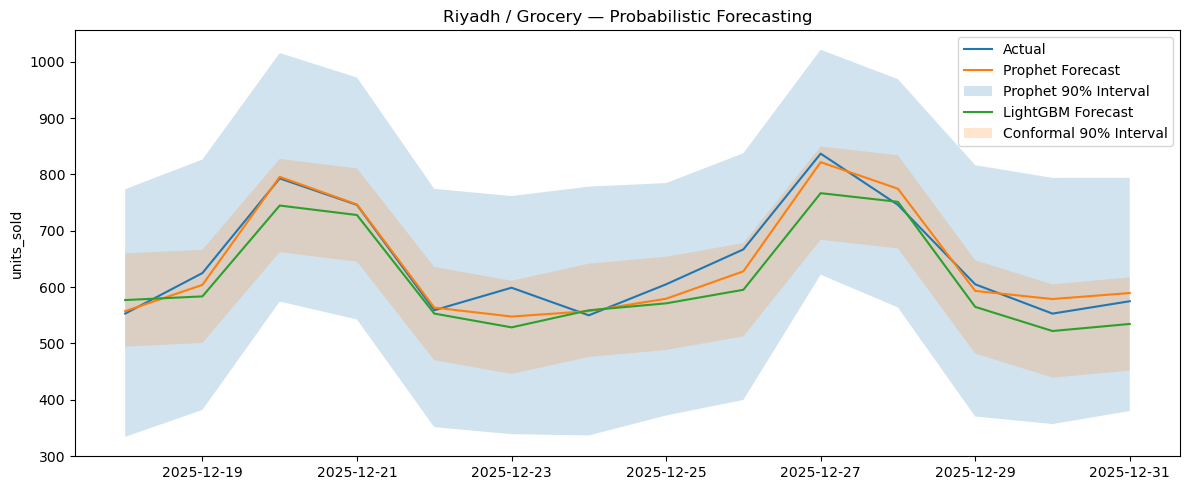

In [10]:

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from prophet import Prophet

from sktime.forecasting.naive import NaiveForecaster
from sktime.performance_metrics.forecasting.probabilistic import PinballLoss



interval_h = min(
    14,
    max(7, len(y) // 12)
)

cal_size = min(
    28,
    max(14, len(y) // 8)
)

origin = len(y) - interval_h

cal_end = origin
cal_start = cal_end - cal_size

cal_series = y.iloc[:cal_start]
cal_actual = y.iloc[cal_start:cal_end]

train_prob = y.iloc[:origin]
future_actual = y.iloc[origin:origin + interval_h]

print("Training observations:", len(train_prob))
print("Calibration observations:", len(cal_actual))
print("Future horizon:", interval_h)



prophet_train = pd.DataFrame({
    "ds": train_prob.index,
    "y": train_prob.values
})

prophet_model = Prophet(
    interval_width=0.90,
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(prophet_train)

prophet_future = prophet_model.make_future_dataframe(
    periods=interval_h,
    freq="D",
    include_history=False
)

prophet_forecast = prophet_model.predict(
    prophet_future
)

prophet_pred = prophet_forecast["yhat"].to_numpy()
prophet_lower = prophet_forecast["yhat_lower"].to_numpy()
prophet_upper = prophet_forecast["yhat_upper"].to_numpy()

prophet_coverage = np.mean(
    (future_actual.values >= prophet_lower)
    &
    (future_actual.values <= prophet_upper)
)

prophet_width = np.mean(
    prophet_upper - prophet_lower
)

print("\nPROPHET")
print("Nominal coverage: 90%")
print(f"Observed coverage: {prophet_coverage:.2%}")
print(f"Mean interval width: {prophet_width:.3f}")

prophet_interval_df = pd.DataFrame(
    {
        "actual": future_actual.values,
        "forecast": prophet_pred,
        "lower": prophet_lower,
        "upper": prophet_upper
    },
    index=future_actual.index
)

display(prophet_interval_df)



sktime_forecaster = NaiveForecaster(
    strategy="last",
    sp=7
)

sktime_forecaster.fit(train_prob)

fh = np.arange(
    1,
    interval_h + 1
)

sktime_interval = sktime_forecaster.predict_interval(
    fh=fh,
    coverage=0.90
)

print("\nSKTIME PREDICTION INTERVAL")
display(sktime_interval)

if isinstance(sktime_interval.columns, pd.MultiIndex):
    lower_col = [
        c for c in sktime_interval.columns
        if str(c[-1]).lower() == "lower"
    ][0]

    upper_col = [
        c for c in sktime_interval.columns
        if str(c[-1]).lower() == "upper"
    ][0]

    sktime_lower = sktime_interval[lower_col].to_numpy()
    sktime_upper = sktime_interval[upper_col].to_numpy()

else:
    sktime_lower = sktime_interval.iloc[:, 0].to_numpy()
    sktime_upper = sktime_interval.iloc[:, 1].to_numpy()


sktime_coverage = np.mean(
    (future_actual.values >= sktime_lower)
    &
    (future_actual.values <= sktime_upper)
)

sktime_width = np.mean(
    sktime_upper - sktime_lower
)

print("Nominal coverage: 90%")
print(f"Observed coverage: {sktime_coverage:.2%}")
print(f"Mean interval width: {sktime_width:.3f}")



quantile_levels = [
    0.10,
    0.90
]

sktime_quantiles = sktime_forecaster.predict_quantiles(
    fh=fh,
    alpha=quantile_levels
)

print("\nSKTIME QUANTILE FORECAST")
display(sktime_quantiles)



pinball_loss_metric = PinballLoss(
    alpha=quantile_levels
)

pinball_loss = pinball_loss_metric.evaluate(
    future_actual,
    sktime_quantiles
)

print(f"\nPinball Loss: {float(pinball_loss):.6f}")


cal_feat = make_features(
    cal_series
).dropna()

cal_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=15,
    reg_lambda=1.0,
    random_state=SEED,
    verbosity=-1
)

cal_model.fit(
    cal_feat[feature_cols],
    cal_feat["y"]
)


hist = cal_series.copy()
cal_preds = []

for dt in cal_actual.index:

    x = make_feature_row(
        hist,
        dt
    )

    pred = float(
        cal_model.predict(x)[0]
    )

    cal_preds.append(pred)

    hist.loc[dt] = cal_actual.loc[dt]



abs_errors = np.abs(
    cal_actual.values
    -
    np.asarray(cal_preds)
)

# 90% conformal radius
q = np.quantile(
    abs_errors,
    0.90,
    method="higher"
)


future_pred = recursive_gbm_forecast(
    y.iloc[:origin],
    interval_h
)

conformal_lower = future_pred - q
conformal_upper = future_pred + q


# Coverage
conformal_coverage = np.mean(
    (future_actual.values >= conformal_lower.values)
    &
    (future_actual.values <= conformal_upper.values)
)

# Width
conformal_width = np.mean(
    conformal_upper.values
    -
    conformal_lower.values
)

print("\nCONFORMAL PREDICTION")
print("Nominal coverage: 90%")
print(
    f"Observed coverage: "
    f"{conformal_coverage:.2%}"
)
print(
    f"Mean interval width: "
    f"{conformal_width:.3f} units"
)

conformal_df = pd.DataFrame(
    {
        "actual": future_actual.values,
        "forecast": future_pred.values,
        "lower": conformal_lower.values,
        "upper": conformal_upper.values
    },
    index=future_actual.index
)

display(conformal_df)



probabilistic_summary = pd.DataFrame({
    "Method": [
        "Prophet",
        "sktime",
        "Conformal"
    ],
    "Nominal Coverage": [
        0.90,
        0.90,
        0.90
    ],
    "Observed Coverage": [
        prophet_coverage,
        sktime_coverage,
        conformal_coverage
    ],
    "Mean Interval Width": [
        prophet_width,
        sktime_width,
        conformal_width
    ]
})

print("\nPROBABILISTIC FORECAST COMPARISON")
display(probabilistic_summary)

print(
    f"\nSktime Pinball Loss: "
    f"{float(pinball_loss):.6f}"
)



fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    future_actual.index,
    future_actual.values,
    label="Actual"
)

ax.plot(
    future_actual.index,
    prophet_pred,
    label="Prophet Forecast"
)

ax.fill_between(
    future_actual.index,
    prophet_lower,
    prophet_upper,
    alpha=0.20,
    label="Prophet 90% Interval"
)

ax.plot(
    future_actual.index,
    future_pred.values,
    label="LightGBM Forecast"
)

ax.fill_between(
    future_actual.index,
    conformal_lower.values,
    conformal_upper.values,
    alpha=0.20,
    label="Conformal 90% Interval"
)

ax.set_title(
    "Riyadh / Grocery — Probabilistic Forecasting"
)

ax.set_ylabel("units_sold")
ax.legend()

plt.tight_layout()
plt.show()

## 7. Model Comparison & Deployment Recommendation

The forecasting approaches are compared across four deployment axes: **history length, interpretability, interval support, and compute budget**. The comparison includes the classical SARIMA family, LightGBM with temporal features, Prophet, and the sktime forecasting framework used for probabilistic interval and quantile forecasting.

| Decision axis        | SARIMA                                                                                                         | LightGBM                                                                                                                     | Prophet                                                                                                                                      | sktime                                                                                                                                            |
| -------------------- | -------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------- |
| **History length**   | Works well when the series has enough observations to estimate autoregressive and seasonal structure reliably. | Benefits from sufficient historical examples to learn nonlinear relationships among lag, rolling, and calendar features.     | Designed to model trend and multiple seasonal effects and can be useful when trend/seasonality structure is a major component of the series. | Depends on the underlying forecaster; for this project, `NaiveForecaster(sp=7)` uses recent weekly seasonal history directly.                     |
| **Interpretability** | Relatively transparent through autoregressive, moving-average, differencing, and seasonal terms.               | Less directly interpretable; feature importance can help explain the contribution of lag and calendar variables.             | Trend and seasonal components are explicitly represented and can be inspected separately.                                                    | Interpretability depends on the selected estimator; the forecasting API provides a consistent interface rather than one single model structure.   |
| **Interval support** | Supports model-based forecasting intervals through the fitted statistical model.                               | Does not inherently provide calibrated prediction intervals; conformal prediction can be added as a distribution-free layer. | Produces uncertainty intervals directly with the forecast output.                                                                            | Provides explicit probabilistic APIs such as `predict_interval()` and `predict_quantiles()`.                                                      |
| **Compute budget**   | Repeated fitting and parameter search can become expensive as the candidate space grows.                       | Efficient for tabular temporal features, although recursive forecasting requires repeated prediction steps.                  | Generally practical for a single series, with additional computation when fitting multiple seasonal components.                              | Depends on the underlying estimator; the framework itself provides standardized forecasting interfaces rather than a fixed computational profile. |

### Probabilistic forecasting considerations

Prophet was fitted with a 90% uncertainty interval and evaluated using observed coverage and mean interval width. The sktime forecaster was evaluated through its `predict_interval()` and `predict_quantiles()` APIs, with quantile forecasts scored using Pinball Loss. The LightGBM forecast was augmented with split-conformal prediction so that coverage and interval width could also be measured.

These approaches represent different ways of producing uncertainty information: model-based intervals from Prophet, explicit interval/quantile APIs through sktime, and a distribution-free conformal layer applied to the LightGBM forecast.

### Model selection framework

The final deployment choice should be based on the observed walk-forward results together with the four decision axes above. Accuracy metrics such as MAE, RMSE, MASE, and WAPE provide evidence about predictive performance, while interval coverage and width provide evidence about uncertainty quality.

For this daily Riyadh grocery series, the selected approach should therefore be the one that provides an appropriate balance between predictive error, weekly seasonal behavior, interpretability, uncertainty support, and computational cost under the intended operating constraints. No single metric is used in isolation.

### Deployment considerations

* **SARIMA** is suitable when an explicit autoregressive and weekly seasonal structure is desirable.
* **LightGBM** is suitable when nonlinear interactions among lagged demand, rolling statistics, and calendar features are important.
* **Prophet** is suitable when trend and seasonal components need to be modeled explicitly together with native uncertainty intervals.
* **sktime** is useful when a standardized forecasting interface and explicit interval/quantile forecasting APIs are required, with the selected estimator determining the underlying forecasting behavior.

The observed backtest metrics, probabilistic coverage, interval width, and computational requirements should be recorded alongside this comparison as the quantitative evidence supporting the final deployment decision.
